# <span style="color:rgb(65, 118, 49)">触媒充填塔反応器について</span>

固体触媒による反応装置として充填塔型反応器がよく使われています。英語ではPacked Bed Reactorと表現しますので、頭文字をとって以降はPBRと略記します。まずは、

[反応器の種類](https://youtu.be/51t-SNs1IFc)
をクリックして、動画を見てください。反応器の種類が紹介されます。その中にPBRがあります。続いて、PBRでの反応のイメージを以下のリンクで見てください。この動画は、液液反応をイメージしたものですが、本講義で対象とする反応流体の主役は気体になります。

[FBR concept](https://youtube.com/shorts/qp6em0fQ6yg)

PBRにおける反応の最前線は固体触媒表面上での反応です。そのイメージ動画です。

[固体触媒イメージ](https://youtu.be/44OU4JxEK4k)

---


<figure style="text-align:center;">
  <img
    src="https://raw.githubusercontent.com/myokota812/lecture/master/AdvChE/figure/pfr.svg"
    width="300">
<figcaption>PFR概略図</figcaption>
</figure>

固定床触媒反応器では、反応物が触媒粒子を充填した触媒層を通過することで化学反応が進行します。本図では反応物が下部から上向きに流れ、触媒層内で反応した後、生成物流として上部から排出される様子を示しています。固定床反応器は圧力損失、伝熱、および反応速度の評価が重要であり、化学工業における気相・液相触媒反応プロセスで広く利用されております。
塔の中には触媒粒子が充填されております。この粒子の間隙を通って反応流体が流れていきます。反応装置の設計をはじめる前にまずは、固定充填塔内の流動特性について考えていきましょう。

## 充填塔（Packed Column）の流動特性：圧力損失

配管内を流体が流れると、壁などとの摩擦により、圧力が低減します。学部の化学工学Iにおいて、直管を流れる流体の圧力損失 $\Delta P$ は以下の式で求めたことを思い出してください。


$$
\Delta P=4f\left(\frac{L}{D}\right)\left(\frac{1}{2}\rho u^2 \right)
$$

 $f$: 摩擦損失係数（Re数の関数),

 $L,D$: 直管の長さと内径,

 $\rho$: 流体密度,

 $u$: 流体線速度

 この場合は、管内には流体以外には何もないので, 線速度 $u$ は空筒速度となります。

さてこの管内にびっしりと、固体触媒粒子が充填されると圧力損失 $\Delta P$ はどうなると思いますか？



$$ 
\begin{array}{c} \uparrow ~\textrm{Outlet}\newline \left\lbrack \begin{array}{c} \bigcirc \bigcirc \bigcirc \bigcirc \newline \bigcirc \bigcirc \bigcirc \newline \bigcirc \bigcirc \bigcirc \bigcirc \newline \bigcirc \bigcirc \bigcirc \newline \bigcirc \bigcirc \bigcirc \bigcirc  \end{array}\right\rbrack \\
\uparrow ~\textrm{Inlet}
\end{array} 
$$

流体の流路を考えてみます。

1. **粘性**：粒子に挟まれた流路は極めて小さいため、流速が大きくなり、流体との摩擦が大きくなり、圧力損失がより大きくなります。
2. **慣性**：ランダムに充填された、粒子間にできる流路は、複雑な形状になります。粒子間に流れ込むところでは、流路が急縮小します。そのほかにも流れが曲がったり、急拡大するところもあります。これらは全て、流体の持つエネルギーの損失になります。

粘性と慣性の合算で、圧力が損失することになります。

充填塔内の流体の動きは複雑なため、厳密に解析的に圧力損失の式を導出することは無理なため、経験式が使われております。代表的なものがErgunの式です（下式）。

 $$
 \frac{\Delta P}{L}=\underset{\textrm{摩擦項（粘性支配）}}{\underbrace{\frac{150(1-\varepsilon )^2 \,\mu \,u}{\varepsilon^3 \,d_p^2 }} } \;+\;\underset{\textrm{慣性項（乱流支配）}}{\underbrace{\frac{1.75(1-\varepsilon )\,\rho \,u^2 }{\varepsilon^3 \,d_p }} } \tag{Ergunの式}
 $$ 　Ergunの式

&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160;
$$\begin{array}{l} L:\textrm{管路長}\newline \epsilon :\textrm{空隙率}\left(=1-\frac{\textrm{充填粒子体積}}{\textrm{反応器体積}}\right)\newline D:\textrm{粒子代表径}\newline \mu :\textrm{流体粘度}\newline \rho :\textrm{流体密度}\newline u:\textrm{空塔線速度} \end{array}$$

それでは、Ergunの式を使って、縦軸に圧力損失（単位長さあたり）、横軸に空塔線速度をプロットしてみましょう。下のコードを（セクション実行）してください。Ergunの式右辺第１項と第２項も一緒にプロットしております。出力されるグラフをよくみてください。


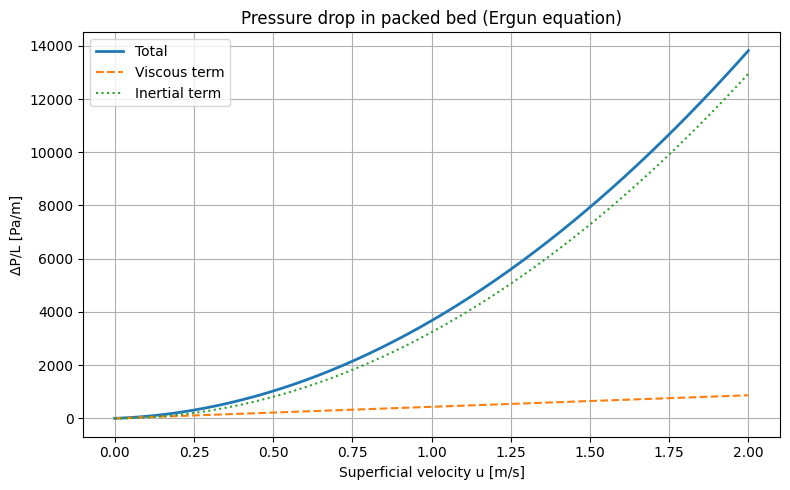

In [5]:
# Ergun式による圧力損失 vs 空塔速度プロット

import numpy as np
import matplotlib.pyplot as plt

# --- 物性（空気：25°C） ---
rho = 1.184        # 密度 [kg/m^3]
mu = 1.85e-5       # 粘度 [Pa·s]

# --- 充填物 ---
dp = 6e-3          # 粒子径 [m]（6 mm）
eps = 0.40         # 空隙率

# --- 空塔速度 ---
u = np.linspace(0, 2.0, 200)   # [m/s]

# --- Ergun式 ---
term1 = (
    150 * (1 - eps)**2 * mu * u
    / (eps**3 * dp**2)
)  # 粘性項

term2 = (
    1.75 * (1 - eps) * rho * u**2
    / (eps**3 * dp)
)  # 慣性項

dP_dL = term1 + term2  # 合計

# --- プロット ---
plt.figure(figsize=(8, 5))

plt.plot(u, dP_dL, linewidth=2, label='Total')
plt.plot(u, term1, '--', linewidth=1.5, label='Viscous term')
plt.plot(u, term2, ':', linewidth=1.5, label='Inertial term')

plt.xlabel('Superficial velocity u [m/s]')
plt.ylabel('ΔP/L [Pa/m]')
plt.title('Pressure drop in packed bed (Ergun equation)')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


予想通り、空塔速度に伴って、圧力損失が増加することがわかります。さらに、この図の横軸のレンジにおいては、慣性項が支配的であることもわかります。それでは、空塔速度が小さいところをフォーカスしてみましょう。上記コードの

<pre>
% --- 空塔速度 ---
u = np.linspace(0, 2.0, 200)   # [m/s]
</pre>

のところで数値の2.0を0.2に変更して実行してください。

低 $u$ において、逆転するのがわかりますね。

このときの数値をグラフから読み取ると、おおよそ $u^*$ =0.134 m/sとなります。

# <span style="color:rgb(213,80,0)">課題：</span>

本日の課題は５つです。解答は

- 本mlxファイルにタイプ入力
- 手書きで解答し、スキャンデータ(PDF)を提出
- Word等で解答

いずれでも結構です。

**課題１**：Ergun方程式の右辺(RHS)において、RHS第１項＝RHS項２となる遷移流速 $u^*$ を、 $\varepsilon$, $u$, $\rho$, $\mu$ の関数として表しなさい。

さらに、Code Ergunの物性値を代入して、 $u^*$ 計算してください。 先ほどグラフから読み取った値と一致しているか記述してください。

解答欄：　u\* =  (ここに記入してください）

#### 解答例=====

RHS第１項＝RHS項２より

$$\frac{150(1-\varepsilon )^2 \,\mu \,u}{\varepsilon^3 \,d_p^2 }=\frac{1.75(1-\varepsilon )\,\rho \,u^2 }{\varepsilon^3 \,d_p }$$

 $u$ について整理すると：

$$u^* =\frac{150}{1.75}\,\frac{(1-\varepsilon )\,\mu }{\rho \,d_p }$$

先ほどのCodeの数値を代入すると

$$\begin{array}{l} u^* =\frac{150}{1.75}\,\frac{0.6\times \,1.85\times 10^{-5} }{1.184\times \,6\times 10^{-3} }\newline =0.134 \end{array}$$

ほぼ一致している。

 **課題2**

$$\frac{\Delta P}{L}=\frac{150(1-\varepsilon )^2 \,\mu \,u}{\varepsilon^3 \,d_p^2 }\;+\;\frac{1.75(1-\varepsilon )\,\rho \,u^2 }{\varepsilon^3 \,d_p }$$

のErgun式の両辺を ある式 (\*)で除することによって、粒子Reynolds数( $Re_p =\frac{\rho ud_p }{\mu }$ )を含む、 無次元式を導出しなさい。

\*(hint):最初にRHSのどちらかの項を無次元にすることを考えると、"ある式"が具体化されます。 $\varepsilon$ は無次元であるので、残したままでかまいません。

**解答欄**(最終的な式を記載。導出過程は不要）：



LaTeX入力に挑戦する人は上記の式をコピペ利用してください。

テキスト入力の場合は、左辺は無次元であることを確認したら、別の記号一文字で置き換えてもらって結構です

#### 解答例=====

$$\frac{\Delta P}{L}=\frac{150(1-\varepsilon )^2 \,\mu \,u}{\varepsilon^3 \,d_p^2 }\;+\;\frac{1.75(1-\varepsilon )\,\rho \,u^2 }{\varepsilon^3 \,d_p }$$

の両辺 を $\frac{\rho u^2 }{d_p }$ で割ると

$$\frac{\Delta P}{L}\frac{d_P }{\rho u^2 }=\frac{150(1-\varepsilon )^2 \,\mu \,u}{\varepsilon^3 \,d_p^2 }\frac{d_P }{\rho u^2 }\;+\;\frac{1.75(1-\varepsilon )\,\rho \,u^2 }{\varepsilon^3 \,d_p }\frac{d_P }{\rho u^2 }$$

$$\frac{\Delta P\;d_P }{\rho \;u^2 \:L}=\frac{150(1-\varepsilon )^2 }{\varepsilon^3 }\frac{\mu }{d_p \:\rho \:u}\;+\;\frac{1.75(1-\varepsilon )}{\varepsilon^3 }$$

左辺の次元は

$$\left\lbrack \frac{\mathrm{M}\;\mathrm{L}}{{\mathrm{T}}^2 {\mathrm{L}}^2 }\frac{\mathrm{L}}{-}\frac{{\mathrm{L}}^3 }{\mathrm{M}}\frac{{\mathrm{T}}^2 }{{\mathrm{L}}^2 }\frac{-}{\mathrm{L}}\right\rbrack =[-]$$

で無次元。右辺第１項の $\frac{\mu }{d_p \:\rho \:u}=\frac{1}{Re}$ なので、結局

$$\Phi =\frac{150(1-\varepsilon )^2 }{\varepsilon^3 }\frac{1}{Re}\;+\;\frac{1.75(1-\varepsilon )}{\varepsilon^3 }$$

の無次元式となる。

**課題3** 課題2で誘導した無次元方程式の左辺には $Re$, $\varepsilon$ とは別の無次元数がでてきます。その無次元数の物理的意味を述べてください。

**解答欄**

**課題4** 装置設計の観点からは管の内径 $D$ が欲しいところです。Ergunの方程式を $D$ を含む方程式に変更するにはどうしたらよいでしょうか。また、結果の式も記入してください。テキスト入力の場合は、面倒でも　A/(BC)^2 = PQ のように書いてくだいさい。

**解答欄**

**課題5　本日の講義では反応速度は一切出てきませんでした。しかし、PBRの設計には、特に圧力損失は重要です。なぜだと思いますか。**

**解答欄**  （できるだけ詳しく記述してください。どこまで推敲されているかを評価します）